In [ ]:
!git clone  https://github.com/MisbahKhan0009/Dehazing

In [6]:
# 1) Import Libraries and Set Seed
import os
import math
import random
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

try:
    from skimage.metrics import peak_signal_noise_ratio as sk_psnr, structural_similarity as sk_ssim
except Exception as e:
    sk_psnr = None
    sk_ssim = None
    print("skimage not available; PSNR/SSIM will be limited.")

# Optional: Albumentations for stronger augmentations
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    _HAS_A = True
except Exception:
    _HAS_A = False

# Optional: morphology and stats for ROI-based metrics
try:
    from skimage.morphology import dilation, disk
    _HAS_SK_MORPH = True
except Exception:
    _HAS_SK_MORPH = False
try:
    from scipy.stats import ks_2samp
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

# Device and reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = (
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('mps') if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else
    torch.device('cpu')
)
print(f"Using device: {device}")

# Performance toggles for high-memory GPUs (CUDA)
if device.type == 'cuda':
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    except Exception:
        pass
    try:
        torch.set_float32_matmul_precision('high')
    except Exception:
        pass

# Multi-GPU detection (DataParallel)
n_gpus = torch.cuda.device_count() if device.type == 'cuda' else 0
if n_gpus > 1:
    print(f"Multi-GPU detected: {n_gpus} GPUs will be used with DataParallel.")

torch.backends.cudnn.benchmark = True  # set False for fully deterministic


Using device: cuda
Multi-GPU detected: 2 GPUs will be used with DataParallel.


In [ ]:
# 2) Configure Hyperparameters and Paths
from dataclasses import dataclass

@dataclass
class Config:
    # Data
    image_size: int = 256
    in_channels: int = 3
    base_channels: int = 64
    val_split: float = 0.1
    num_workers: int = 4

    # Training
    batch_size: int = 8
    epochs: int = 200
    lr: float = 2e-4
    betas: Tuple[float, float] = (0.5, 0.999)
    lambda_l1: float = 100.0
    mixed_precision: bool = True
    grad_clip_norm: float | None = 1.0
    accumulate_steps: int = 1  # set >1 to simulate larger batch size

    # Performance/DataLoader
    persistent_workers: bool = True  # requires num_workers > 0
    prefetch_factor: int = 2        # requires num_workers > 0
    drop_last: bool = True
    channels_last: bool = True

    # Paths (Kaggle environment - absolute paths)
    data_clean_dir: str = "/kaggle/working/Dehazing/Dataset/clean"
    data_noisy_dir: str = "/kaggle/working/Dehazing/Dataset/noisy"
    data_roi_dir: str = "/kaggle/working/Dehazing/Dataset/noisy_roi"
    output_dir: str = "/kaggle/working/Dehazing/Notebooks/checkpoints/gan_denoising"

cfg = Config()

# Resolve paths - use absolute paths directly
clean_dir = Path(cfg.data_clean_dir).resolve()
noisy_dir = Path(cfg.data_noisy_dir).resolve()
roi_dir = Path(cfg.data_roi_dir).resolve()
out_dir = Path(cfg.output_dir).resolve()
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Clean images dir: {clean_dir}")
print(f"Noisy images dir: {noisy_dir}")
print(f"ROI masks dir:    {roi_dir}")
print(f"Output dir:       {out_dir}")


Clean images dir: /kaggle/working/Dehazing/Dataset/clean
Noisy images dir: /kaggle/working/Dehazing/Dataset/noisy
ROI masks dir:    /kaggle/working/Dehazing/Dataset/noisy_roi
Output dir:       /kaggle/working/Dehazing/Notebooks/checkpoints/gan_denoising


In [8]:
# 3) Prepare Dataset and Dataloaders (REAL noisy/clean pairs from folders)

def _to_uint8(img: np.ndarray) -> np.ndarray:
    img = np.clip(img, 0, 1)
    return (img * 255.0 + 0.5).astype(np.uint8)

class RealPairedDataset(Dataset):
    """
    Loads real paired clean/noisy images from Dataset/clean and Dataset/noisy.
    Matches pairs by filename stem (e.g., patient-1234-4C-frame-01.png).
    Handles both grayscale and RGB images (converts grayscale to RGB).
    Optionally loads ROI masks from Dataset/noisy_roi for CNR/gCNR evaluation.
    """
    def __init__(self, clean_root: Path, noisy_root: Path, image_size: int = 256, use_albu: bool = False):
        print("Loading dataset...")
        
        # Gather clean images
        print("  Scanning clean images...")
        clean_paths = []
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
            clean_paths.extend(sorted(clean_root.rglob(ext)))
        if not clean_paths:
            raise FileNotFoundError(f"No clean images found in {clean_root}")
        print(f"    Found {len(clean_paths)} clean images")
        
        # Build dict: stem -> clean path
        clean_map = {p.stem: p for p in clean_paths}
        
        # Gather noisy images and match to clean
        print("  Scanning noisy images...")
        noisy_paths = []
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
            noisy_paths.extend(sorted(noisy_root.rglob(ext)))
        if not noisy_paths:
            raise FileNotFoundError(f"No noisy images found in {noisy_root}")
        print(f"    Found {len(noisy_paths)} noisy images")
        
        # Only keep pairs where both clean and noisy exist
        print("  Matching clean/noisy pairs by filename stem...")
        self.pairs = []
        for np_path in tqdm(noisy_paths, desc="  Matching pairs", leave=False):
            stem = np_path.stem
            if stem in clean_map:
                self.pairs.append((clean_map[stem], np_path))
        
        if not self.pairs:
            raise ValueError(f"No matching clean/noisy pairs found. Check filenames in {clean_root} and {noisy_root}.")
        
        print(f"✓ Found {len(self.pairs)} matching clean/noisy pairs.")
        
        self.image_size = image_size
        self.use_albu = use_albu and _HAS_A
        if self.use_albu:
            # Apply same transform to both clean and noisy
            self.albu_tf = A.Compose([
                A.LongestMaxSize(max_size=image_size),
                A.PadIfNeeded(image_size, image_size, border_mode=0, value=(0,0,0)),
                A.RandomCrop(image_size, image_size),
                A.HorizontalFlip(p=0.5),
            ], additional_targets={'noisy': 'image'})
        else:
            self.pil_tf = transforms.Compose([
                transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            ])

    def __len__(self):
        return len(self.pairs)

    def _read_rgb(self, path: Path) -> np.ndarray:
        """Read image and convert to RGB (handles grayscale automatically)"""
        with Image.open(path) as im:
            # Convert grayscale to RGB if needed
            if im.mode != 'RGB':
                im = im.convert('RGB')
            return np.array(im).astype(np.float32) / 255.0

    def _to_tensor_norm(self, arr: np.ndarray) -> torch.Tensor:
        # Normalize to [-1,1]
        t = torch.from_numpy(arr.transpose(2,0,1)).float()
        t = t * 2.0 - 1.0
        return t

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        clean_path, noisy_path = self.pairs[idx]
        clean = self._read_rgb(clean_path)
        noisy = self._read_rgb(noisy_path)
        
        if self.use_albu:
            # Apply same spatial transform to both
            aug = self.albu_tf(image=clean, noisy=noisy)
            clean = aug['image']
            noisy = aug['noisy']
        else:
            clean = np.array(self.pil_tf(Image.fromarray(_to_uint8(clean))))/255.0
            noisy = np.array(self.pil_tf(Image.fromarray(_to_uint8(noisy))))/255.0
        
        return {
            'noisy': self._to_tensor_norm(noisy),
            'clean': self._to_tensor_norm(clean),
            'path': str(clean_path)
        }

# Build datasets and loaders
print("\n" + "="*60)
print("Building Dataset and DataLoaders")
print("="*60)
full_ds = RealPairedDataset(clean_dir, noisy_dir, image_size=cfg.image_size, use_albu=True)
val_len = max(1, int(len(full_ds) * cfg.val_split))
train_len = len(full_ds) - val_len
train_ds, val_ds = random_split(full_ds, [train_len, val_len], generator=torch.Generator().manual_seed(seed))

def _make_loader(ds, bsz, shuffle):
    # persistent_workers and prefetch_factor require num_workers > 0
    pw = cfg.persistent_workers and (cfg.num_workers > 0)
    pf = cfg.prefetch_factor if cfg.num_workers > 0 else None
    return DataLoader(
        ds, batch_size=bsz, shuffle=shuffle, num_workers=cfg.num_workers, pin_memory=True,
        persistent_workers=pw, prefetch_factor=pf, drop_last=cfg.drop_last
    )

print(f"\nCreating DataLoaders...")
train_loader = _make_loader(train_ds, cfg.batch_size, True)
val_loader   = _make_loader(val_ds,   cfg.batch_size, False)

print(f"✓ Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")
print(f"✓ Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print(f"✓ Batch size: {cfg.batch_size}, Image size: {cfg.image_size}")
print("="*60 + "\n")

len(train_ds), len(val_ds)



Building Dataset and DataLoaders
Loading dataset...
  Scanning clean images...
    Found 4376 clean images
  Scanning noisy images...
    Found 2324 noisy images
  Matching clean/noisy pairs by filename stem...


✓ Found 2324 matching clean/noisy pairs.

Creating DataLoaders...
✓ Train samples: 2092, Val samples: 232
✓ Train batches: 261, Val batches: 29
✓ Batch size: 8, Image size: 256



/tmp/ipykernel_37/4062397971.py:57: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(image_size, image_size, border_mode=0, value=(0,0,0)),


(2092, 232)

Mean absolute difference (noisy vs clean): 0.0962
  -> If this is ~0, images are identical (BAD). Should be clearly > 0.01 for real pairs.
ROI directory not found at /kaggle/working/Dataset/noisy_roi. CNR/gCNR will default to NaN.


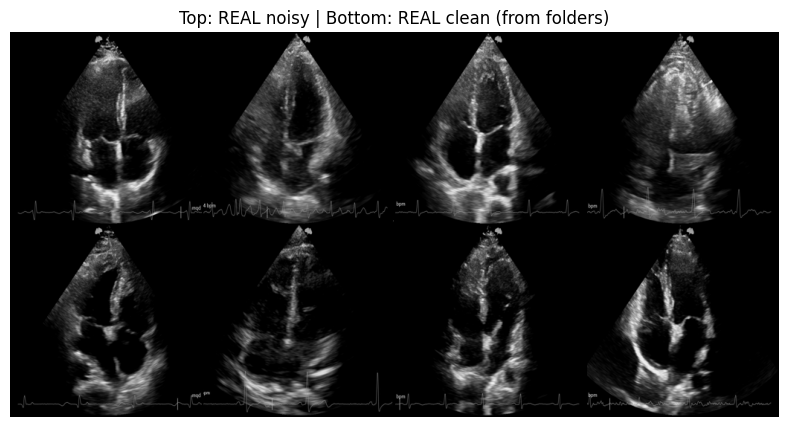

In [ ]:
# 4) Preview Noisy vs Clean Samples and Validate Pairing

def denorm(t: torch.Tensor) -> torch.Tensor:
    # from [-1,1] to [0,1]
    return (t.clamp(-1,1) + 1.0) * 0.5

batch = next(iter(train_loader))
noisy_b = denorm(batch['noisy'])
clean_b = denorm(batch['clean'])

# Quick visual check: compute mean absolute difference
diff = (noisy_b - clean_b).abs().mean().item()
print(f"Mean absolute difference (noisy vs clean): {diff:.4f}")
print(f"  -> If this is ~0, images are identical (BAD). Should be clearly > 0.01 for real pairs.")

# Check if ROI masks exist for any of these samples
if roi_dir.exists():
    roi_found = 0
    for p in batch['path'][:4]:
        stem = Path(p).stem
        for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']:
            if (roi_dir / f"{stem}{ext}").exists():
                roi_found += 1
                break
    print(f"ROI masks found for {roi_found}/4 samples in this batch (CNR/gCNR will be computed where available).")
else:
    print(f"ROI directory not found at {roi_dir}. CNR/gCNR will default to NaN.")

# Visualize
show_b = torch.cat([noisy_b[:4], clean_b[:4]], dim=0)
grid = make_grid(show_b, nrow=4)
plt.figure(figsize=(10,5))
plt.axis('off')
plt.title('Top: REAL noisy | Bottom: REAL clean (from folders)')
plt.imshow(grid.permute(1,2,0).cpu().numpy())
plt.show()


In [10]:
# 5) Define Generator (U-Net)
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, norm='in'):
        super().__init__()
        Norm = nn.InstanceNorm2d if norm=='in' else nn.BatchNorm2d
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            Norm(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            Norm(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch, norm='in'):
        super().__init__()
        self.pool = nn.AvgPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch, norm)
    def forward(self, x):
        return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True, norm='in'):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch, norm)
        else:
            self.up = nn.ConvTranspose2d(in_ch//2, in_ch//2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch, norm)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Pad x1 to match x2 size
        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [diffX // 2, diffX - diffX//2, diffY // 2, diffY - diffY//2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base=64, bilinear=True, norm='in'):
        super().__init__()
        self.inc = DoubleConv(in_channels, base, norm)
        self.down1 = Down(base, base*2, norm)
        self.down2 = Down(base*2, base*4, norm)
        self.down3 = Down(base*4, base*8, norm)
        self.down4 = Down(base*8, base*8, norm)
        self.up1 = Up(base*16, base*4, bilinear, norm)
        self.up2 = Up(base*8, base*2, bilinear, norm)
        self.up3 = Up(base*4, base, bilinear, norm)
        self.up4 = Up(base*2, base, bilinear, norm)
        self.outc = OutConv(base, out_channels)
        self.tanh = nn.Tanh()
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        x = self.outc(x)
        return self.tanh(x)

gen = UNetGenerator(in_channels=cfg.in_channels, out_channels=cfg.in_channels, base=cfg.base_channels).to(device)
if cfg.channels_last and device.type == 'cuda':
    gen = gen.to(memory_format=torch.channels_last)
# Wrap with DataParallel if multiple GPUs are available
if device.type == 'cuda' and torch.cuda.device_count() > 1:
    gen = nn.DataParallel(gen)
print(f"Generator params: {sum(p.numel() for p in gen.parameters())/1e6:.2f}M")


Generator params: 13.38M


In [11]:
# 6) Define PatchGAN Discriminator
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, norm=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=stride, padding=1, bias=not norm)]
        if norm:
            layers.append(nn.InstanceNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)

class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=3, base=64):
        super().__init__()
        # Input is concatenation of noisy and target/generated: 2*in_channels
        self.model = nn.Sequential(
            # no norm in first block
            ConvBlock(in_channels*2, base, stride=2, norm=False),
            ConvBlock(base, base*2, stride=2, norm=True),
            ConvBlock(base*2, base*4, stride=2, norm=True),
            # stride=1 at the last conv before out
            ConvBlock(base*4, base*8, stride=1, norm=True),
            nn.Conv2d(base*8, 1, kernel_size=4, stride=1, padding=1)
        )
    def forward(self, x_noisy, x_target):
        x = torch.cat([x_noisy, x_target], dim=1)
        return self.model(x)

disc = PatchDiscriminator(in_channels=cfg.in_channels, base=cfg.base_channels).to(device)
if cfg.channels_last and device.type == 'cuda':
    disc = disc.to(memory_format=torch.channels_last)
# Wrap with DataParallel if multiple GPUs are available
if device.type == 'cuda' and torch.cuda.device_count() > 1:
    disc = nn.DataParallel(disc)
print(f"Discriminator params: {sum(p.numel() for p in disc.parameters())/1e6:.2f}M")


Discriminator params: 2.77M


In [12]:
# 7) Define Losses (Adversarial + L1) and Optimizers
bce_logits = nn.BCEWithLogitsLoss().to(device)
l1_loss = nn.L1Loss().to(device)

opt_g = torch.optim.Adam(gen.parameters(), lr=cfg.lr, betas=cfg.betas)
opt_d = torch.optim.Adam(disc.parameters(), lr=cfg.lr, betas=cfg.betas)

scaler = torch.cuda.amp.GradScaler(enabled=(cfg.mixed_precision and device.type=='cuda'))

# Optional scheduler
scheduler_g = torch.optim.lr_scheduler.CosineAnnealingLR(opt_g, T_max=cfg.epochs)
scheduler_d = torch.optim.lr_scheduler.CosineAnnealingLR(opt_d, T_max=cfg.epochs)


/tmp/ipykernel_37/2200002375.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.mixed_precision and device.type=='cuda'))


In [13]:
# 6.5) Multi-GPU Diagnostics and Batch Size Recommendation

if device.type == 'cuda':
    n_gpus = torch.cuda.device_count()
    print(f"\n{'='*60}")
    print(f"GPU Configuration:")
    print(f"{'='*60}")
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        mem_total = props.total_memory / 1e9
        mem_alloc = torch.cuda.memory_allocated(i) / 1e9
        mem_reserved = torch.cuda.memory_reserved(i) / 1e9
        print(f"GPU {i}: {props.name}")
        print(f"  Total memory:    {mem_total:.2f} GB")
        print(f"  Allocated:       {mem_alloc:.3f} GB")
        print(f"  Reserved:        {mem_reserved:.3f} GB")
        print(f"  Free (approx):   {mem_total - mem_reserved:.2f} GB")
    
    if n_gpus > 1:
        print(f"\n✓ DataParallel is enabled across {n_gpus} GPUs")
        print(f"  Current batch size: {cfg.batch_size}")
        recommended_batch = cfg.batch_size * n_gpus
        print(f"  Recommended batch size for better GPU utilization: {recommended_batch}")
        print(f"\nTo scale batch size, run after this cell:")
        print(f"  cfg.batch_size = {recommended_batch}")
        print(f"  train_loader = _make_loader(train_ds, cfg.batch_size, True)")
        print(f"  val_loader = _make_loader(val_ds, cfg.batch_size, False)")
        print(f"\nOr use the helper at the end:")
        print(f"  rebuild_loaders(new_batch_size={recommended_batch})")
    else:
        print(f"\nℹ Only 1 GPU detected; DataParallel not active.")
    print(f"{'='*60}\n")
else:
    print("CPU mode - no GPU diagnostics available.")



GPU Configuration:
GPU 0: Tesla T4
  Total memory:    15.83 GB
  Allocated:       0.066 GB
  Reserved:        0.090 GB
  Free (approx):   15.74 GB
GPU 1: Tesla T4
  Total memory:    15.83 GB
  Allocated:       0.000 GB
  Reserved:        0.000 GB
  Free (approx):   15.83 GB

✓ DataParallel is enabled across 2 GPUs
  Current batch size: 8
  Recommended batch size for better GPU utilization: 16

To scale batch size, run after this cell:
  cfg.batch_size = 16
  train_loader = _make_loader(train_ds, cfg.batch_size, True)
  val_loader = _make_loader(val_ds, cfg.batch_size, False)

Or use the helper at the end:
  rebuild_loaders(new_batch_size=16)



In [14]:
# 6.8) Verify DataParallel is Active (Quick Test)

if device.type == 'cuda' and torch.cuda.device_count() > 1:
    print("Testing DataParallel with a forward pass...")
    # Reset memory stats
    for i in range(torch.cuda.device_count()):
        torch.cuda.reset_peak_memory_stats(i)
    
    # Run a test batch through both models
    test_batch = torch.randn(cfg.batch_size, cfg.in_channels, cfg.image_size, cfg.image_size, device=device)
    if cfg.channels_last:
        test_batch = test_batch.to(memory_format=torch.channels_last)
    
    with torch.no_grad():
        _ = gen(test_batch)
        _ = disc(test_batch, test_batch)
    
    # Check memory usage on each GPU
    print("\nMemory usage after test forward pass:")
    all_used = True
    for i in range(torch.cuda.device_count()):
        peak = torch.cuda.max_memory_allocated(i) / 1e6
        print(f"  GPU {i}: {peak:.1f} MB peak")
        if peak < 1.0:  # Less than 1 MB means likely not used
            all_used = False
    
    if all_used:
        print("\n✓ SUCCESS: Both GPUs are being used by DataParallel!")
    else:
        print("\n⚠ WARNING: One or more GPUs show minimal usage.")
        print("  This might be normal for small batches. Try scaling batch size.")
    
    # Clean up
    del test_batch
    torch.cuda.empty_cache()
else:
    print("Multi-GPU test skipped (only 1 GPU or CPU mode).")


Testing DataParallel with a forward pass...

Memory usage after test forward pass:
  GPU 0: 9676.8 MB peak
  GPU 1: 9509.3 MB peak

✓ SUCCESS: Both GPUs are being used by DataParallel!


In [ ]:
# 8) Training Step and Utility Functions (PSNR/SSIM)

def denorm(img_t: torch.Tensor) -> torch.Tensor:
    """Denormalize from [-1,1] to [0,1] for visualization"""
    return (img_t + 1.0) * 0.5

def tensor_to_uint8(img_t: torch.Tensor) -> np.ndarray:
    # img_t in [-1,1]
    img = ((img_t.clamp(-1,1) + 1.0) * 0.5).detach().cpu().numpy()
    img = np.transpose(img, (0,2,3,1))  # N H W C
    img = (img * 255.0 + 0.5).astype(np.uint8)
    return img

@torch.no_grad()
def compute_psnr_ssim_batch(pred: torch.Tensor, target: torch.Tensor) -> Tuple[float, float]:
    if sk_psnr is None or sk_ssim is None:
        return float('nan'), float('nan')
    pred_np = tensor_to_uint8(pred)
    targ_np = tensor_to_uint8(target)
    psnrs, ssims = [], []
    for p, t in zip(pred_np, targ_np):
        psnrs.append(sk_psnr(t, p, data_range=255))
        try:
            ssims.append(sk_ssim(t, p, channel_axis=2, data_range=255))
        except TypeError:
            # Fallback for older skimage
            ssims.append(sk_ssim(t, p, multichannel=True, data_range=255))
    return float(np.mean(psnrs)), float(np.mean(ssims))


def train_step(batch):
    noisy = batch['noisy'].to(device, non_blocking=True)
    clean = batch['clean'].to(device, non_blocking=True)
    if cfg.channels_last and device.type == 'cuda':
        noisy = noisy.contiguous(memory_format=torch.channels_last)
        clean = clean.contiguous(memory_format=torch.channels_last)

    valid = torch.ones((noisy.size(0), 1, 30, 30), device=device)  # shape will be adjusted dynamically below
    fake = torch.zeros_like(valid)

    # Adjust valid/fake shape by running one disc forward on zeros to get map size
    with torch.no_grad():
        dshape = disc(noisy, clean).shape
    valid = torch.ones(dshape, device=device)
    fake = torch.zeros(dshape, device=device)

    # 1) Update Discriminator
    opt_d.zero_grad(set_to_none=True)
    with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
        gen_clean = gen(noisy)
        d_real = disc(noisy, clean)
        d_fake = disc(noisy, gen_clean.detach())
        loss_d_real = bce_logits(d_real, valid)
        loss_d_fake = bce_logits(d_fake, fake)
        loss_d = (loss_d_real + loss_d_fake) * 0.5
    scaler.scale(loss_d).backward()
    if cfg.grad_clip_norm:
        scaler.unscale_(opt_d)
        torch.nn.utils.clip_grad_norm_(disc.parameters(), cfg.grad_clip_norm)
    scaler.step(opt_d)

    # 2) Update Generator
    opt_g.zero_grad(set_to_none=True)
    with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
        gen_clean = gen(noisy)
        d_fake = disc(noisy, gen_clean)
        adv_loss = bce_logits(d_fake, valid)
        l1 = l1_loss(gen_clean, clean)
        loss_g = adv_loss + cfg.lambda_l1 * l1
    scaler.scale(loss_g).backward()
    if cfg.grad_clip_norm:
        scaler.unscale_(opt_g)
        torch.nn.utils.clip_grad_norm_(gen.parameters(), cfg.grad_clip_norm)
    scaler.step(opt_g)
    scaler.update()

    return {
        'loss_d': loss_d.item(),
        'loss_g': loss_g.item(),
        'adv': adv_loss.item(),
        'l1': l1.item(),
    }


In [ ]:
# 9) Train Loop with Checkpointing and Logging
import csv
from datetime import datetime

ckpt_dir = out_dir
(ckpt_dir / 'samples').mkdir(parents=True, exist_ok=True)
log_csv = ckpt_dir / 'epoch_results.csv'
log_txt = ckpt_dir / 'epoch_results.txt'

best_metric = -float('inf')

def _unwrap_dp(m: nn.Module) -> nn.Module:
    return m.module if isinstance(m, nn.DataParallel) else m

def save_checkpoint(path: Path, epoch: int):
    state = {
        'epoch': epoch,
        'gen': _unwrap_dp(gen).state_dict(),
        'disc': _unwrap_dp(disc).state_dict(),
        'opt_g': opt_g.state_dict(),
        'opt_d': opt_d.state_dict(),
        'scaler': scaler.state_dict() if scaler.is_enabled() else None,
        'cfg': vars(cfg),
    }
    torch.save(state, str(path))


def load_checkpoint(path: Path):
    state = torch.load(path, map_location=device)
    _unwrap_dp(gen).load_state_dict(state['gen'])
    _unwrap_dp(disc).load_state_dict(state['disc'])
    opt_g.load_state_dict(state['opt_g'])
    opt_d.load_state_dict(state['opt_d'])
    if state.get('scaler') and scaler.is_enabled():
        scaler.load_state_dict(state['scaler'])
    return state.get('epoch', 0)


#############################################
## ROI-based metrics: CNR, gCNR, KS (optional)
#############################################
def _to_gray01(img_chw: torch.Tensor) -> np.ndarray:
    # img is tensor in [-1,1], shape CxHxW
    img01 = (img_chw.clamp(-1,1) + 1.0) * 0.5
    if img01.shape[0] == 1:
        gray = img01[0].detach().cpu().numpy()
    else:
        r,g,b = img01[0], img01[1], img01[2]
        gray = (0.299*r + 0.587*g + 0.114*b).detach().cpu().numpy()
    return np.clip(gray, 0.0, 1.0)

def compute_cnr(sig_vals: np.ndarray, bg_vals: np.ndarray) -> float:
    if sig_vals.size < 2 or bg_vals.size < 2:
        return float('nan')
    mu_s, mu_b = sig_vals.mean(), bg_vals.mean()
    var_s, var_b = sig_vals.var(ddof=1), bg_vals.var(ddof=1)
    denom = np.sqrt(var_s + var_b) + 1e-8
    return float(abs(mu_s - mu_b) / denom)

def compute_gcnr(sig_vals: np.ndarray, bg_vals: np.ndarray, bins: int = 256) -> float:
    if sig_vals.size < 2 or bg_vals.size < 2:
        return float('nan')
    hist_s, _ = np.histogram(sig_vals, bins=bins, range=(0,1), density=True)
    hist_b, _ = np.histogram(bg_vals,  bins=bins, range=(0,1), density=True)
    overlap = np.minimum(hist_s, hist_b).sum() * (1.0/bins)  # approximate integral
    gcnr = 1.0 - float(overlap)
    return float(np.clip(gcnr, 0.0, 1.0))

def compute_ks(sig_vals: np.ndarray, bg_vals: np.ndarray) -> tuple[float, float]:
    if not _HAS_SCIPY or sig_vals.size < 2 or bg_vals.size < 2:
        return float('nan'), float('nan')
    res = ks_2samp(sig_vals, bg_vals)
    return float(res.statistic), float(res.pvalue)

def _load_roi_mask_for_stem(stem: str) -> np.ndarray | None:
    # Use the configured roi_dir instead of hardcoded path
    if not roi_dir.exists():
        return None
    for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']:
        cand = roi_dir / f"{stem}{ext}"
        if cand.exists():
            with Image.open(cand) as im:
                m = np.array(im.convert('L'))
            # binarize: any non-zero -> ROI
            return (m > 0).astype(np.uint8)
    return None

def _derive_bg_ring(roi_mask: np.ndarray, inner_px: int = 5, outer_px: int = 10) -> np.ndarray | None:
    if not _HAS_SK_MORPH:
        return None
    roi = roi_mask.astype(bool)
    if roi.sum() == 0:
        return None
    selem_in  = disk(max(1, inner_px))
    selem_out = disk(max(1, outer_px))
    dil_in  = dilation(roi, selem_in)
    dil_out = dilation(roi, selem_out)
    ring = np.logical_and(dil_out, np.logical_not(dil_in))
    # remove borders if any padding issues
    return ring.astype(np.uint8)

def _sample_vals(gray01: np.ndarray, roi_mask: np.ndarray, ring_mask: np.ndarray | None) -> tuple[np.ndarray, np.ndarray]:
    sig_vals = gray01[roi_mask.astype(bool)]
    if ring_mask is None or ring_mask.sum() == 0:
        # fallback: background is non-ROI
        bg_vals = gray01[np.logical_not(roi_mask.astype(bool))]
    else:
        bg_vals = gray01[ring_mask.astype(bool)]
    # guard against empties
    if sig_vals.size == 0 or bg_vals.size == 0:
        return np.array([]), np.array([])
    return sig_vals, bg_vals

def _compute_roi_metrics_for_tensor(img_chw: torch.Tensor, path_str: str) -> dict:
    # Find mask by filename stem
    stem = Path(path_str).stem
    mask = _load_roi_mask_for_stem(stem)
    if mask is None:
        return {'cnr': float('nan'), 'gcnr': float('nan'), 'ks': float('nan'), 'ksp': float('nan')}
    gray = _to_gray01(img_chw)
    # Resize mask to match image size if needed
    if mask.shape != gray.shape:
        mask_pil = Image.fromarray(mask * 255)
        mask_pil = mask_pil.resize((gray.shape[1], gray.shape[0]), Image.NEAREST)
        mask = (np.array(mask_pil) > 0).astype(np.uint8)
    ring = _derive_bg_ring(mask)
    sig_vals, bg_vals = _sample_vals(gray, mask, ring)
    if sig_vals.size == 0 or bg_vals.size == 0:
        return {'cnr': float('nan'), 'gcnr': float('nan'), 'ks': float('nan'), 'ksp': float('nan')}
    cnr  = compute_cnr(sig_vals, bg_vals)
    gcnr = compute_gcnr(sig_vals, bg_vals)
    ks, ksp = compute_ks(sig_vals, bg_vals)
    return {'cnr': cnr, 'gcnr': gcnr, 'ks': ks, 'ksp': ksp}


def validate(epoch: int, max_batches: int = None):
    """
    Validate the model on the validation set.
    If max_batches is None, use all validation batches.
    """
    gen.eval()
    losses_g, losses_d, psnrs, ssims = [], [], [], []
    cnrs, gcnrs, kss = [], [], []
    
    # Use all batches if max_batches not specified
    num_batches = len(val_loader) if max_batches is None else min(max_batches, len(val_loader))
    
    with torch.no_grad():
        for bi, batch in enumerate(val_loader):
            if max_batches is not None and bi >= max_batches:
                break
            noisy = batch['noisy'].to(device, non_blocking=True)
            clean = batch['clean'].to(device, non_blocking=True)
            
            # Forward pass
            gen_clean = gen(noisy)
            d_fake = disc(noisy, gen_clean)
            d_real = disc(noisy, clean)
            
            # Compute losses
            loss_d = 0.5*(bce_logits(d_real, torch.ones_like(d_real)) + bce_logits(d_fake, torch.zeros_like(d_fake)))
            adv_loss = bce_logits(d_fake, torch.ones_like(d_fake))
            l1 = l1_loss(gen_clean, clean)
            loss_g = adv_loss + cfg.lambda_l1 * l1
            losses_g.append(loss_g.item())
            losses_d.append(loss_d.item())
            
            # Compute PSNR/SSIM
            p, s = compute_psnr_ssim_batch(gen_clean, clean)
            if not np.isnan(p): psnrs.append(p)
            if not np.isnan(s): ssims.append(s)
            
            # ROI metrics per item (if ROI mask exists)
            if 'path' in batch:
                for i, pth in enumerate(batch['path']):
                    m = _compute_roi_metrics_for_tensor(gen_clean[i].cpu(), pth)
                    if not np.isnan(m['cnr']): cnrs.append(m['cnr'])
                    if not np.isnan(m['gcnr']): gcnrs.append(m['gcnr'])
                    if not np.isnan(m['ks']): kss.append(m['ks'])
    gen.train()
    
    return {
        'loss_g': float(np.mean(losses_g)) if losses_g else float('nan'),
        'loss_d': float(np.mean(losses_d)) if losses_d else float('nan'),
        'psnr': float(np.mean(psnrs)) if psnrs else float('nan'),
        'ssim': float(np.mean(ssims)) if ssims else float('nan'),
        'cnr':  float(np.mean(cnrs))  if cnrs  else float('nan'),
        'gcnr': float(np.mean(gcnrs)) if gcnrs else float('nan'),
        'ks':   float(np.mean(kss))   if kss   else float('nan'),
    }

def visualize_samples(epoch: int, batch, save: bool = True):
    gen.eval()
    with torch.no_grad():
        noisy = batch['noisy'].to(device, non_blocking=True)[:4]
        clean = batch['clean'].to(device, non_blocking=True)[:4]
        denoised = gen(noisy)
    show = torch.cat([denorm(noisy), denorm(denoised), denorm(clean)], dim=0)
    grid = make_grid(show, nrow=4)
    plt.figure(figsize=(10,8))
    plt.axis('off')
    plt.title(f'Epoch {epoch}: Row1 noisy | Row2 denoised | Row3 clean')
    plt.imshow(grid.permute(1,2,0).cpu().numpy())
    if save:
        img_path = ckpt_dir / 'samples' / f'epoch_{epoch:04d}.png'
        plt.savefig(img_path, bbox_inches='tight')
        print(f"  Saved visualization to {img_path.name}")
    plt.show()
    gen.train()

# Prepare CSV log
if not log_csv.exists():
    with open(log_csv, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['epoch','loss_g','loss_d','val_loss_g','val_loss_d','val_psnr','val_ssim','val_cnr','val_gcnr','val_ks','timestamp'])

start_epoch = 0
resume_path = ckpt_dir / 'last.pt'
if resume_path.exists():
    print(f"Resuming from: {resume_path}")
    start_epoch = load_checkpoint(resume_path) + 1

print("\n" + "="*60)
print("Starting Training")
print("="*60)

for epoch in range(start_epoch, cfg.epochs):
    gen.train(); disc.train()
    running = {'loss_g':0.0,'loss_d':0.0,'adv':0.0,'l1':0.0}
    pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1}/{cfg.epochs}")
    for bi, batch in enumerate(pbar):
        mets = train_step(batch)
        for k in running:
            running[k] += mets.get(k, 0.0)
        # Update tqdm postfix occasionally with quick PSNR on current batch
        if (bi+1) % 50 == 0:
            with torch.no_grad():
                noisy_ = batch['noisy'].to(device, non_blocking=True)
                clean_ = batch['clean'].to(device, non_blocking=True)
                pred_ = gen(noisy_)
                psnr_batch, _ = compute_psnr_ssim_batch(pred_, clean_)
            pbar.set_postfix({
                'loss_g': f"{running['loss_g']/(bi+1):.3f}",
                'loss_d': f"{running['loss_d']/(bi+1):.3f}",
                'psnr': f"{psnr_batch:.2f}",
            })
    
    # Close progress bar before validation
    pbar.close()
    
    # Validation
    print(f"\nEpoch {epoch+1} - Running validation...")
    val_m = validate(epoch)

    print(f"Epoch {epoch+1} Results:")
    print(f"  Train - Loss G: {running['loss_g']/max(1,len(train_loader)):.4f}, Loss D: {running['loss_d']/max(1,len(train_loader)):.4f}")
    print(f"  Val   - Loss G: {val_m['loss_g']:.4f}, Loss D: {val_m['loss_d']:.4f}")
    print(f"  Val   - PSNR: {val_m['psnr']:.2f}, SSIM: {val_m['ssim']:.4f}")
    print(f"  Val   - CNR: {val_m['cnr']:.3f}, gCNR: {val_m['gcnr']:.3f}, KS: {val_m['ks']:.3f}")

    # Logging
    with open(log_csv, 'a', newline='') as f:
        w = csv.writer(f)
        w.writerow([
            epoch,
            running['loss_g']/max(1,len(train_loader)),
            running['loss_d']/max(1,len(train_loader)),
            val_m['loss_g'], val_m['loss_d'], val_m['psnr'], val_m['ssim'], val_m['cnr'], val_m['gcnr'], val_m['ks'],
            datetime.now().isoformat(timespec='seconds')
        ])
    with open(log_txt, 'a') as f:
        f.write(f"Epoch {epoch}: {val_m}\n")

    # Visualization (use a small val batch)
    print(f"  Generating visualization...")
    try:
        batch_vis = next(iter(val_loader))
        visualize_samples(epoch, batch_vis, save=True)
    except StopIteration:
        print("  Warning: No validation data available for visualization")

    # Save checkpoints
    save_checkpoint(ckpt_dir / 'last.pt', epoch)

    # Track best by SSIM, fallback to PSNR if NaN
    metric = val_m['ssim']
    if np.isnan(metric):
        metric = val_m['psnr'] if not np.isnan(val_m['psnr']) else -float('inf')
    if metric > best_metric:
        best_metric = metric
        save_checkpoint(ckpt_dir / 'best.pt', epoch)
        print(f"  ✓ Saved new best checkpoint (metric={best_metric:.4f})")

    # Step schedulers
    scheduler_g.step(); scheduler_d.step()
    print("-"*60)

print("\n" + "="*60)
print("Training finished!")
print("="*60)


Epoch 1/200:   0%|          | 0/261 [00:00<?, ?it/s]/tmp/ipykernel_37/1956949685.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
/tmp/ipykernel_37/1956949685.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
Epoch 1/200:  42%|████▏     | 110/261 [03:06<04:10,  1.66s/it, loss_g=45.829, loss_d=0.102, psnr=14.78]

In [ ]:
# 10) Validate and Visualize Results (on full val set)
@torch.no_grad()
def evaluate_full_val(save_images: bool = True):
    gen.eval()
    all_psnr, all_ssim = [], []
    for bi, batch in enumerate(val_loader):
        noisy = batch['noisy'].to(device)
        clean = batch['clean'].to(device)
        denoised = gen(noisy)
        p, s = compute_psnr_ssim_batch(denoised, clean)
        if not np.isnan(p): all_psnr.append(p)
        if not np.isnan(s): all_ssim.append(s)
        if save_images and bi < 3:
            show = torch.cat([denorm(noisy[:4]), denorm(denoised[:4]), denorm(clean[:4])], dim=0)
            grid = make_grid(show, nrow=4)
            plt.figure(figsize=(10,8))
            plt.axis('off')
            plt.title(f'Val batch {bi}: noisy | denoised | clean')
            plt.imshow(grid.permute(1,2,0).cpu().numpy())
            plt.show()
    mean_psnr = float(np.mean(all_psnr)) if all_psnr else float('nan')
    mean_ssim = float(np.mean(all_ssim)) if all_ssim else float('nan')
    print(f"Full Val -> PSNR: {mean_psnr:.3f}, SSIM: {mean_ssim:.4f}")
    return mean_psnr, mean_ssim

In [ ]:
# 11) Save, Load, and Export Model (TorchScript/ONNX)

def export_torchscript(ts_path: Path | str = None):
    ts_path = Path(ts_path) if ts_path else (ckpt_dir / 'generator_scripted.pt')
    G = gen.module if isinstance(gen, nn.DataParallel) else gen
    G.eval()
    dummy = torch.randn(1, cfg.in_channels, cfg.image_size, cfg.image_size, device=device)
    traced = torch.jit.trace(G, dummy)
    traced.save(str(ts_path))
    print(f"Saved TorchScript to {ts_path}")


def export_onnx(onnx_path: Path | str = None):
    onnx_path = Path(onnx_path) if onnx_path else (ckpt_dir / 'generator.onnx')
    G = gen.module if isinstance(gen, nn.DataParallel) else gen
    G.eval()
    dummy = torch.randn(1, cfg.in_channels, cfg.image_size, cfg.image_size, device=device)
    torch.onnx.export(
        G, dummy, str(onnx_path),
        input_names=['noisy'], output_names=['denoised'],
        dynamic_axes={'noisy': {0: 'batch'}, 'denoised': {0: 'batch'}},
        opset_version=13
    )
    print(f"Saved ONNX to {onnx_path}")


In [ ]:
# 12) Inference on Single Image from Disk
from torchvision.transforms.functional import to_tensor

@torch.no_grad()
def denoise_image(path_in: str | Path, path_out: str | Path = None):
    path_in = Path(path_in)
    if path_out is None:
        path_out = ckpt_dir / f"denoised_{path_in.stem}.png"
    else:
        path_out = Path(path_out)

    img = Image.open(path_in).convert('RGB')
    arr = np.array(img).astype(np.float32) / 255.0
    h, w, _ = arr.shape

    # Pad to multiple of 16 for U-Net
    def _pad_to_multiple(x, base=16):
        nh = (h + base - 1)//base*base
        nw = (w + base - 1)//base*base
        pad_h = nh - h
        pad_w = nw - w
        x = np.pad(x, ((0,pad_h),(0,pad_w),(0,0)), mode='reflect')
        return x, pad_h, pad_w

    arr_pad, ph, pw = _pad_to_multiple(arr, 16)
    t = torch.from_numpy(arr_pad.transpose(2,0,1)).float().unsqueeze(0)
    t = t*2-1
    t = t.to(device)

    gen.eval()
    out = gen(t)
    out = (out.clamp(-1,1)+1)/2.0
    out = out.squeeze(0).permute(1,2,0).detach().cpu().numpy()
    # Unpad
    out = out[:h, :w, :]
    out = (out*255.0+0.5).astype(np.uint8)
    Image.fromarray(out).save(path_out)
    print(f"Saved denoised image to {path_out}")

# Example usage (uncomment after training):
# denoise_image('Dataset/noisy/example.png')

In [ ]:
# 13) Lightweight Unit Tests for Shapes and Forward Pass
# These tests are safe to run before training to validate shapes.

def run_unit_tests():
    print("Running unit tests...")
    G = UNetGenerator(in_channels=cfg.in_channels, out_channels=cfg.in_channels, base=cfg.base_channels).to(device)
    D = PatchDiscriminator(in_channels=cfg.in_channels, base=cfg.base_channels).to(device)

    x = torch.randn(2, cfg.in_channels, cfg.image_size, cfg.image_size, device=device)
    y = torch.randn(2, cfg.in_channels, cfg.image_size, cfg.image_size, device=device)

    y_hat = G(x)
    assert y_hat.shape == x.shape, f"Generator output shape mismatch: {y_hat.shape} vs {x.shape}"

    d_out = D(x, y)
    assert d_out.ndim == 4 and d_out.shape[1] == 1, f"Discriminator shape invalid: {d_out.shape}"

    loss_fn = nn.BCEWithLogitsLoss()
    d_loss = loss_fn(d_out, torch.ones_like(d_out))
    assert torch.isfinite(d_loss), "Discriminator loss not finite"

    # One training step should update params
    optg = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.5,0.999))
    optd = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.5,0.999))

    # record a weight
    w_before = next(G.parameters()).detach().clone()

    # simple losses
    d_real = D(x, y)
    d_fake = D(x, G(x).detach())
    ld = 0.5*(loss_fn(d_real, torch.ones_like(d_real)) + loss_fn(d_fake, torch.zeros_like(d_fake)))
    optd.zero_grad(); ld.backward(); optd.step()

    d_fake = D(x, G(x))
    lg = loss_fn(d_fake, torch.ones_like(d_fake)) + 10.0*F.l1_loss(G(x), y)
    optg.zero_grad(); lg.backward(); optg.step()

    w_after = next(G.parameters()).detach().clone()
    assert not torch.allclose(w_before, w_after), "Weights did not update in unit test"
    print("All unit tests passed.")

# run_unit_tests()  # uncomment to run
